In [2]:

#Recomendación pasos a seguir:

#1. Localiza la temática de datos que te gustaría extraer, trabajar y analizar, y encuentra una fuente de datos al respecto. Puede basarte en las propuestas a continuación o buscar una propia.
#2. Inspecciona de manera general el alcance de esa fuente de datos, qué informaciones contiene, cuántas tablas, ficheros, líneas. Cuál es su granularidad (qué representa cada línea de las diferentes tablas de que dispones), el número de variables y su tipo.
#3. Imagina y plantea qué análisis podrías realizar y a que conclusiones podrías llegar, qué querrías explicar o demostrar, y si con esos datos que tienes es posible, si son lo suficientemente ricos.
#4. Extrae los datos. Nunca perdiendo de vista si aquello que planteaste sigue siendo posible de realizar, a medida que vas conociendo mejor los datos.
#5. A continuación, sigue los pasos habituales del análisis exploratorio: limpieza de nulos, gestión de valores extremos, ingeniería de variables, representación y análisis de los datos.



In [3]:
import yfinance as yf
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
# the Magnificent 7 Stocks 
tickers = ["AAPL", "AMZN", "GOOG", "TSLA", "MSFT", "NVDA", "META" ,]

# Fetching historical data that called my attention in order to get more info
start_date = "2000-01-01"
end_date = "2025-03-01"

# Creating a dictionary to store data for the Magnificent 7 Stocks
data = {}

for ticker in tickers:
    stock = yf.Ticker(ticker)
    df = stock.history(start=start_date, end=end_date, interval="3mo")  # Monthly data
    df["Ticker"] = ticker  # Add column to identify the stock
    data[ticker] = df

# Combine data into a single DataFrame
df_stocks = pd.concat(data.values(), axis=0)

# Reset index for better visualization
df_stocks.reset_index(inplace=True)

# Showing a few rows for the Magnificent 7 stocks
df_stocks

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Ticker
0,2000-01-01 00:00:00-05:00,0.789016,1.131331,0.650773,1.021772,28573316800,0.0,0.0,AAPL
1,2000-04-01 00:00:00-05:00,1.019420,1.049514,0.604693,0.788076,26575360000,0.0,2.0,AAPL
2,2000-07-01 00:00:00-04:00,0.784315,0.964876,0.381813,0.387455,25899787200,0.0,0.0,AAPL
3,2000-10-01 00:00:00-04:00,0.401562,0.402502,0.205013,0.223821,39253132800,0.0,0.0,AAPL
4,2001-01-01 00:00:00-05:00,0.223821,0.357361,0.217239,0.332083,31532289600,0.0,0.0,AAPL
...,...,...,...,...,...,...,...,...,...
593,2024-02-01 00:00:00-05:00,392.092070,528.996825,391.206231,428.152130,1182842100,0.5,0.0,META
594,2024-05-01 00:00:00-04:00,427.042122,540.836981,425.557517,473.104065,833431100,0.5,0.0,META
595,2024-08-01 00:00:00-04:00,519.621645,601.354851,449.607354,566.078430,835695500,0.5,0.0,META
596,2024-11-01 00:00:00-04:00,566.648346,709.585764,548.119792,688.012390,818976100,0.5,0.0,META


C:\Users\dmira\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


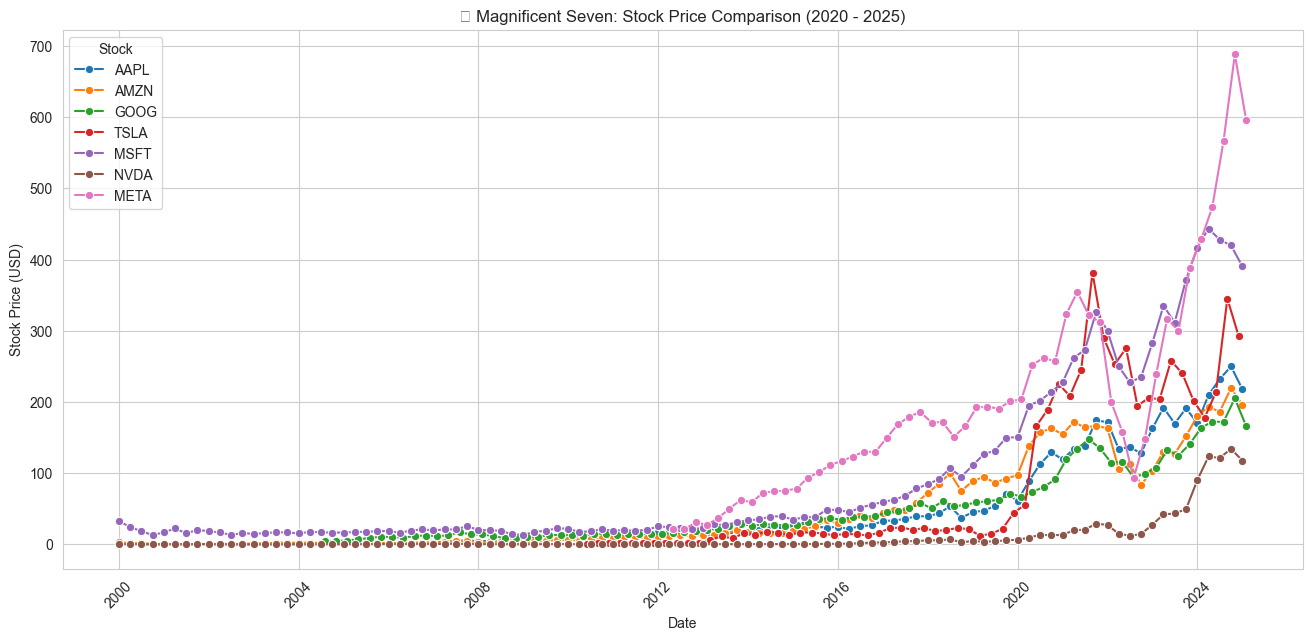

In [5]:
# I will create the chart using the Seaborn library
# Plot style
sns.set_style("whitegrid")

# Creating the plot
plt.figure(figsize=(16, 7))
sns.lineplot(data=df_stocks, x="Date", y="Close", hue="Ticker", marker="o")

# Labels and title
plt.xlabel("Date")
plt.ylabel("Stock Price (USD)")
plt.title("📈 Magnificent Seven: Stock Price Comparison (2020 - 2025)")
plt.legend(title="Stock")

# Rotate x-axis labels for readability
plt.xticks(rotation=45)

# Showing the plot to make the data undestandable for my presentation
plt.show()

In [6]:
# This is for me to know the top holdings of this ETF
spy = yf.Ticker('SPY').funds_data

#Some parameters that I can use to get data for this ETF "SPY". I tried some other like calendar and info but not relevant at all for this case
spy.description
spy.top_holdings

,Name,Holding Percent
Symbol,,
AAPL,Apple Inc,0.072364
NVDA,NVIDIA Corp,0.060659
MSFT,Microsoft Corp,0.058428
AMZN,Amazon.com Inc,0.039326
META,Meta Platforms Inc Class A,0.028836
GOOGL,Alphabet Inc Class A,0.019696
BRK-B,Berkshire Hathaway Inc Class B,0.018645
AVGO,Broadcom Inc,0.018439
GOOG,Alphabet Inc Class C,0.016226


In [62]:
#To know the holding that are part of the MSCI WORLD ETF
spy = yf.Ticker('IWDE.AS').funds_data

#Using some paramters to get interesting data for my presentation
spy.description
spy.top_holdings

,Name,Holding Percent
Symbol,,
AAPL,Apple Inc,0.050509
NVDA,NVIDIA Corp,0.042489
MSFT,Microsoft Corp,0.038933
AMZN,Amazon.com Inc,0.027892
META,Meta Platforms Inc Class A,0.020232
GOOGL,Alphabet Inc Class A,0.013818
AVGO,Broadcom Inc,0.012305
GOOG,Alphabet Inc Class C,0.011913
TSLA,Tesla Inc,0.011717


In [222]:
# I tried to get relevant data for this GLD ETF but the only parameter that works in this case was - description

gld = yf.Ticker('GLD').funds_data


gld.description

#gld.fund_overview
#gld.fund_operations

'The Trust holds gold bars and from time to time, issues Baskets in exchange for deposits of gold and distributes gold in connection with redemptions of Baskets. The investment objective of the Trust is for the Shares to reflect the performance of the price of gold bullion, less the Trust’s expenses. The Sponsor believes that, for many investors, the Shares represent a cost-effective investment in gold.'

In [7]:
# Defining the MSCI WORLD ETF 
ticker = ["IWDA.AS"]

# Fetching historical data that called my attention in order to get more info
start_date = "2000-01-01"
end_date = "2025-03-01"

# Create a dictionary to store data
data = {}

for ticker in ticker:
    msci = yf.Ticker(ticker)
    df = msci.history(start=start_date, end=end_date, interval="3mo")  # Monthly data
    df["Ticker"] = ticker  # Add column to identify the stock
    data[ticker] = df

# Combine data into a single DataFrame
df_msci = pd.concat(data.values(), axis=0)

# Reset index for better visualization
df_msci.reset_index(inplace=True)

# Showing a few rows for this etf
df_msci

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains,Ticker
0,2009-09-01 00:00:00+02:00,16.990000,17.389999,16.459999,16.860001,54190,0.0,0.0,0.0,IWDA.AS
1,2009-12-01 00:00:00+01:00,17.030001,18.620001,17.030001,18.379999,178846,0.0,0.0,0.0,IWDA.AS
2,2010-03-01 00:00:00+01:00,18.559999,20.469999,18.549999,19.549999,157371,0.0,0.0,0.0,IWDA.AS
3,2010-06-01 00:00:00+02:00,19.495001,20.330000,18.320000,19.014999,1121960,0.0,0.0,0.0,IWDA.AS
4,2010-09-01 00:00:00+02:00,19.110001,20.540001,19.100000,20.440001,715391,0.0,0.0,0.0,IWDA.AS
...,...,...,...,...,...,...,...,...,...,...
57,2023-12-01 00:00:00+01:00,79.375000,88.639999,79.300003,88.180000,9850022,0.0,0.0,0.0,IWDA.AS
58,2024-03-01 00:00:00+01:00,88.714996,92.889999,87.919998,90.669998,9940135,0.0,0.0,0.0,IWDA.AS
59,2024-06-01 00:00:00+02:00,92.035004,96.699997,86.370003,95.080002,8395966,0.0,0.0,0.0,IWDA.AS
60,2024-09-01 00:00:00+02:00,95.555000,105.139999,91.605003,104.830002,8779342,0.0,0.0,0.0,IWDA.AS


C:\Users\dmira\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


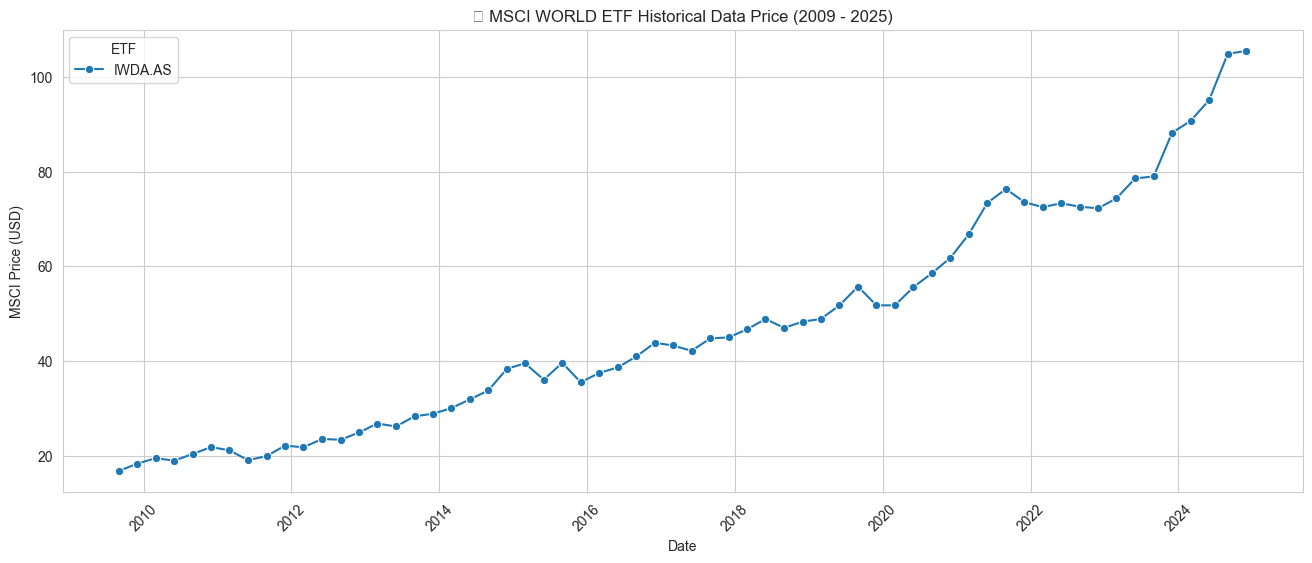

In [8]:
# Set plot style
sns.set_style("whitegrid")

# Create the plot
plt.figure(figsize=(16, 6))
sns.lineplot(data=df_msci, x="Date", y="Close", hue="Ticker", marker="o")

# Labels and title
plt.xlabel("Date")
plt.ylabel("MSCI Price (USD)")
plt.title("📈 MSCI WORLD ETF Historical Data Price (2009 - 2025)")
plt.legend(title="ETF")

# Rotate x-axis labels for readability
plt.xticks(rotation=45)

# Showing the plot to make the data undestandable for my presentation
plt.show()

In [227]:
# Defining the SPY ETF to later on work with it
ticker = ["SPY"]

# Fetching historical data that called my attention in order to get more info
start_date = "2000-01-01"
end_date = "2025-03-01"

# Creating a dictionary to store data
data = {}

for ticker in ticker:
    stock = yf.Ticker(ticker)
    df = stock.history(start=start_date, end=end_date, interval="3mo")  # Monthly data
    df["Ticker"] = ticker  # Add column to identify the stock
    data[ticker] = df

# Combine data into a single DataFrame
df_stocks = pd.concat(data.values(), axis=0)

# Reset index for better visualization
df_stocks.reset_index(inplace=True)

# Showing a few rows to see data that could be useful
df_stocks

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains,Ticker
0,2000-01-01 00:00:00-05:00,94.202055,98.967758,84.333079,95.552338,591304000,0.371,0.0,0.0,SPY
1,2000-04-01 00:00:00-05:00,95.635919,97.537091,85.045097,92.550247,517416200,0.348,0.0,0.0,SPY
2,2000-07-01 00:00:00-04:00,92.867952,98.076060,90.363670,91.710594,322348600,0.375,0.0,0.0,SPY
3,2000-10-01 00:00:00-04:00,92.361077,93.301291,80.358338,83.979164,500509000,0.411,0.0,0.0,SPY
4,2001-01-01 00:00:00-05:00,84.758495,89.060629,69.373545,74.927795,678090600,0.316,0.0,0.0,SPY
...,...,...,...,...,...,...,...,...,...,...
96,2024-01-01 00:00:00-05:00,464.782059,516.412460,459.141584,514.896545,4567343100,1.595,0.0,0.0,SPY
97,2024-04-01 00:00:00-04:00,517.246731,543.364330,487.653351,537.380432,3635161600,1.759,0.0,0.0,SPY
98,2024-07-01 00:00:00-04:00,540.510924,569.318113,505.482654,568.377014,3328125900,1.746,0.0,0.0,SPY
99,2024-10-01 00:00:00-04:00,569.762686,605.206398,561.684253,582.362244,2937428500,1.966,0.0,0.0,SPY


C:\Users\dmira\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


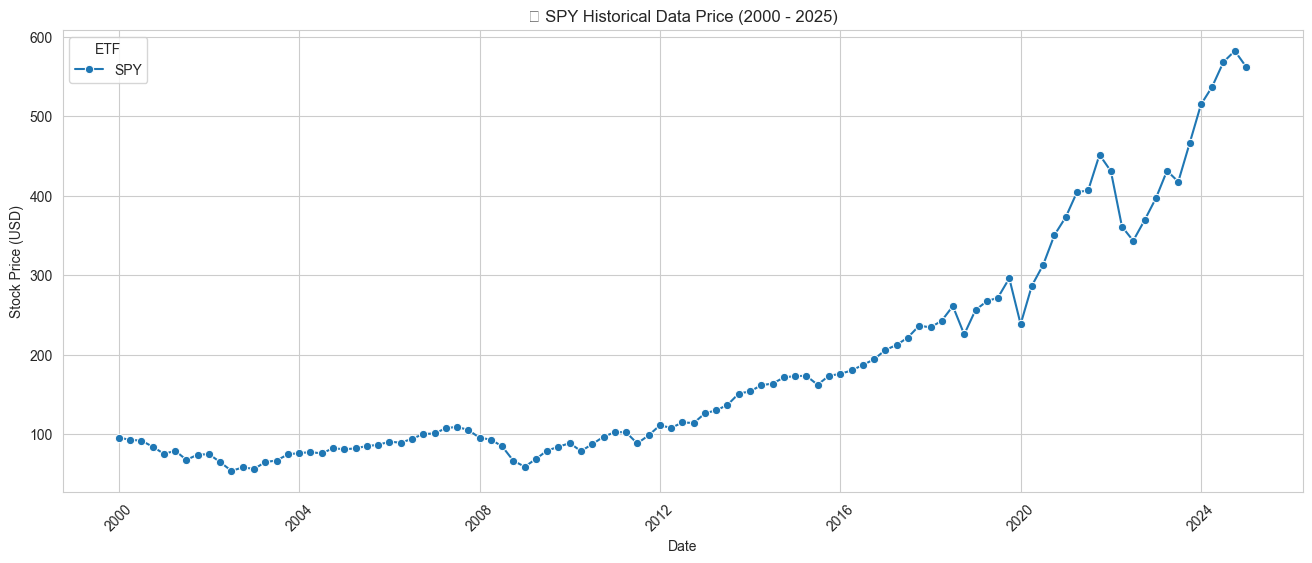

In [228]:
# Set plot style to make it more interesting
sns.set_style("whitegrid")

# Creating the plot
plt.figure(figsize=(16, 6))
sns.lineplot(data=df_stocks, x="Date", y="Close", hue="Ticker", marker="o")

# Labels and title
plt.xlabel("Date")
plt.ylabel("SPY Price (USD)")
plt.title("📈 SPY Historical Data Price (2000 - 2025)")
plt.legend(title="ETF")

# Rotate x-axis labels for readability
plt.xticks(rotation=45)

# Showing the plot to make the data undestandable for my presentation
plt.show()

In [240]:
# Defining the GOLD ETF to later on work with it
ticker = ["GLD"]

# Fetching historical data that called my attention in order to get more info
start_date = "2000-01-01"
end_date = "2025-03-01"

# Creating a dictionary to store data
data = {}

for ticker in ticker:
    fund = yf.Ticker(ticker)
    df = fund.history(start=start_date, end=end_date, interval="3mo")  # Monthly data
    df["Ticker"] = ticker  # Add column to identify the stock
    data[ticker] = df

# Combine data into a single DataFrame
df_fund = pd.concat(data.values(), axis=0)

# Reset index for better visualization
df_fund.reset_index(inplace=True)

# Showing a few rows to get some insights and more ideas
df_fund

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains,Ticker
0,2004-11-01 00:00:00-05:00,45.279999,46.000000,41.700001,42.220001,96332200,0.0,0.0,0.0,GLD
1,2005-02-01 00:00:00-05:00,42.090000,44.669998,41.020000,43.349998,119618800,0.0,0.0,0.0,GLD
2,2005-05-01 00:00:00-04:00,43.130001,44.130001,41.330002,42.820000,101961500,0.0,0.0,0.0,GLD
3,2005-08-01 00:00:00-04:00,43.080002,47.720001,42.810001,46.400002,122369000,0.0,0.0,0.0,GLD
4,2005-11-01 00:00:00-05:00,46.070000,57.049999,45.320000,56.700001,220156300,0.0,0.0,0.0,GLD
...,...,...,...,...,...,...,...,...,...,...
77,2024-02-01 00:00:00-05:00,189.710007,225.089996,183.779999,211.869995,535082200,0.0,0.0,0.0,GLD
78,2024-05-01 00:00:00-04:00,212.960007,229.649994,210.710007,226.550003,389214100,0.0,0.0,0.0,GLD
79,2024-08-01 00:00:00-04:00,226.740005,257.709991,220.110001,253.509995,423801300,0.0,0.0,0.0,GLD
80,2024-11-01 00:00:00-04:00,254.330002,259.989990,236.130005,258.559998,409624400,0.0,0.0,0.0,GLD


C:\Users\dmira\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


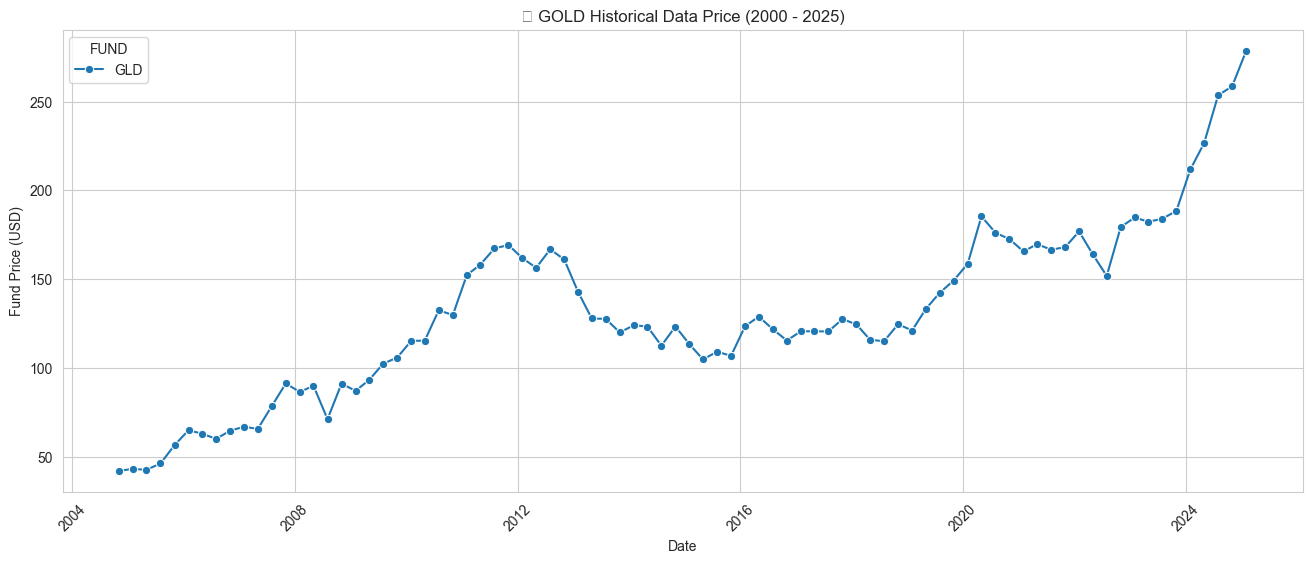

In [241]:
# Set plot style to make it visually more interesting
sns.set_style("whitegrid")

# Creating the plot
plt.figure(figsize=(16, 6))
sns.lineplot(data=df_fund, x="Date", y="Close", hue="Ticker", marker="o")

# Labels and title
plt.xlabel("Date")
plt.ylabel("Fund Price (USD)")
plt.title("📈 GOLD Historical Data Price (2000 - 2025)")
plt.legend(title="FUND")

# Rotate x-axis labels for readability
plt.xticks(rotation=45)

# Showing the plot to make the data undestandable for my presentation
plt.show()

In [235]:
# Defining the ETF from Grayscale for BTC
ticker = ["GBTC"]

# Fetching historical data that called my attention in order to get more info
start_date = "2015-01-01"
end_date = "2025-03-01"

# Creating a dictionary to store data
data = {}

for ticker in ticker:
    crypto = yf.Ticker(ticker)
    df = crypto.history(start=start_date, end=end_date, interval="3mo")  # Monthly data
    df["Ticker"] = ticker  # Add column to identify the stock
    data[ticker] = df

# Combine data into a single DataFrame
df_crypto = pd.concat(data.values(), axis=0)

# Reset index for better visualization
df_crypto.reset_index(inplace=True)

# Showing a few rows for this etf
df_crypto

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains,Ticker
0,2015-05-01 00:00:00-04:00,0.362637,0.362637,0.307692,0.331319,18454800,0.0,0.0,0.0,GBTC
1,2015-08-01 00:00:00-04:00,0.335165,0.372527,0.233187,0.372527,19355700,0.0,0.0,0.0,GBTC
2,2015-11-01 00:00:00-04:00,0.376484,0.796703,0.376484,0.472527,71553300,0.0,0.0,0.0,GBTC
3,2016-02-01 00:00:00-05:00,0.469780,0.873626,0.439560,0.787912,28037100,0.0,0.0,0.0,GBTC
4,2016-05-01 00:00:00-04:00,0.787912,1.582418,0.659341,1.043956,71398600,0.0,0.0,0.0,GBTC
5,2016-08-01 00:00:00-04:00,1.000000,1.185714,0.823077,1.185714,25762100,0.0,0.0,0.0,GBTC
6,2016-11-01 00:00:00-04:00,1.208791,1.670330,1.016484,1.192253,93639000,0.0,0.0,0.0,GBTC
7,2017-02-01 00:00:00-05:00,1.208791,1.571429,1.126374,1.513187,141632400,0.0,0.0,0.0,GBTC
8,2017-05-01 00:00:00-04:00,1.581923,6.208791,1.571538,4.615385,404868100,0.0,0.0,0.0,GBTC
9,2017-08-01 00:00:00-04:00,4.563077,11.702747,4.384615,9.102857,412230000,0.0,0.0,0.0,GBTC


C:\Users\dmira\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


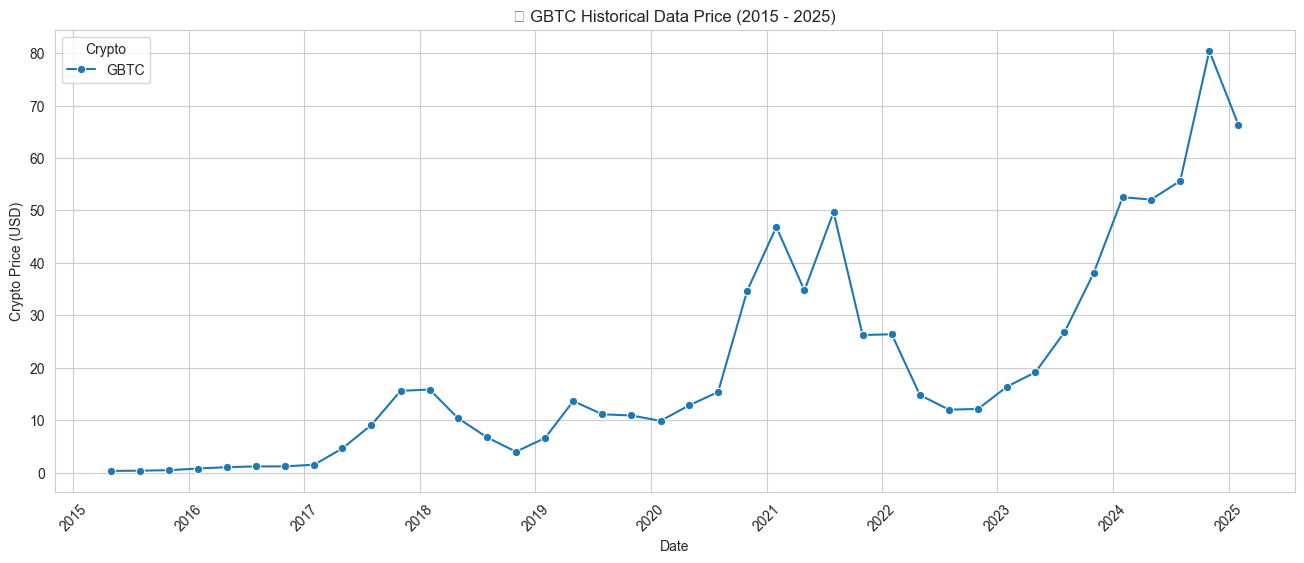

In [239]:
# Set plot style to visually make it more interesting
sns.set_style("whitegrid")

# Creating the plot
plt.figure(figsize=(16, 6))
sns.lineplot(data=df_crypto, x="Date", y="Close", hue="Ticker", marker="o")

# Labels and title
plt.xlabel("Date")
plt.ylabel("Crypto Price (USD)")
plt.title("📈 GBTC Historical Data Price (2015 - 2025)")
plt.legend(title="Crypto")

# Rotate x-axis labels for readability
plt.xticks(rotation=45)

# Showing the plot
plt.show()

In [237]:
# Combining all the ETFS to see what insights can i get from it
tickers = ["IWDA.AS", "SPY", "GLD", "GBTC"]

# Fetch historical data to compare the data between different assets
start_date = "2000-01-01"
end_date = "2025-03-01"

# Creating a dictionary to store data
data = {}

for ticker in tickers:
    etfs = yf.Ticker(ticker)
    df = etfs.history(start=start_date, end=end_date, interval="3mo")  # Monthly data
    df["Ticker"] = ticker  # Add column to identify the stock
    data[ticker] = df

# Combining data into a single DataFrame so i can get the chart 
df_etfs = pd.concat(data.values(), axis=0)

# Reset index for better visualization
df_etfs.reset_index(inplace=True)

# Showing few rows
df_etfs

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains,Ticker
0,2009-09-01 00:00:00+02:00,16.990000,17.389999,16.459999,16.860001,54190,0.0,0.0,0.0,IWDA.AS
1,2009-12-01 00:00:00+01:00,17.030001,18.620001,17.030001,18.379999,178846,0.0,0.0,0.0,IWDA.AS
2,2010-03-01 00:00:00+01:00,18.559999,20.469999,18.549999,19.549999,157371,0.0,0.0,0.0,IWDA.AS
3,2010-06-01 00:00:00+02:00,19.495001,20.330000,18.320000,19.014999,1121960,0.0,0.0,0.0,IWDA.AS
4,2010-09-01 00:00:00+02:00,19.110001,20.540001,19.100000,20.440001,715391,0.0,0.0,0.0,IWDA.AS
...,...,...,...,...,...,...,...,...,...,...
280,2024-02-01 00:00:00-05:00,37.840000,65.610001,37.730000,52.509998,935585200,0.0,0.0,0.0,GBTC
281,2024-05-01 00:00:00-04:00,51.320000,63.900002,48.794998,52.070000,311312000,0.0,0.0,0.0,GBTC
282,2024-08-01 00:00:00-04:00,51.560001,58.599998,39.560001,55.610001,252307700,0.0,0.0,0.0,GBTC
283,2024-11-01 00:00:00-04:00,55.799999,86.110001,53.369999,80.410004,250200900,0.0,0.0,0.0,GBTC


C:\Users\dmira\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


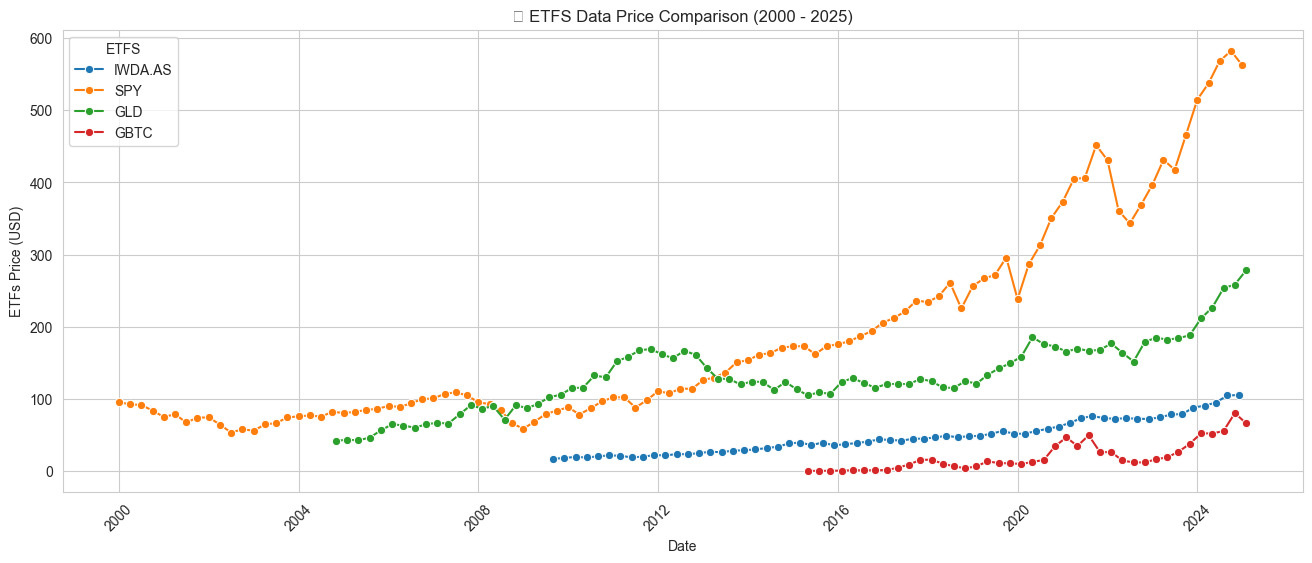

In [238]:
# Set plot style
sns.set_style("whitegrid")

# Creating the plot
plt.figure(figsize=(16, 6))
sns.lineplot(data=df_etfs, x="Date", y="Close", hue="Ticker", marker="o")

# Labels and title
plt.xlabel("Date")
plt.ylabel("ETFs Price (USD)")
plt.title("📈 ETFS Data Price Comparison (2000 - 2025)")
plt.legend(title="ETFS")

# Rotate x-axis labels for readability
plt.xticks(rotation=45)

# Show the plot to see the performance of each etf
plt.show()